# Student Final Score Prediction: EDA, Feature Engineering, and MAE-Based Model Comparison

**Competition:** CS Week Codeathon AIML (Easy Level)

**Author:** [Amey Thakur](https://www.kaggle.com/ameythakur20)

**Objective:** Predict `final_score` from academic and lifestyle variables.

## Introduction

This notebook analyzes the student score dataset, examines feature relationships with `final_score`, adds interaction-based and quadratic features, compares regression models with cross-validated MAE, and generates a submission file.

## Table of Contents

1. [Data Acquisition](#1-data-acquisition)
2. [Data Inspection](#2-data-inspection)
3. [Data Cleaning](#3-data-cleaning)
4. [EDA](#4-eda)
5. [Feature Engineering](#5-feature-engineering)
6. [Modeling](#6-modeling)
7. [Evaluation](#7-evaluation)
8. [Conclusion](#8-conclusion)
9. [References](#9-references)

## 1. Data Acquisition

In [1]:
# Imports for data handling, visualization, preprocessing, and modeling
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports for regression and evaluation
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Optional libraries available in many Kaggle environments
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
    LGBM_AVAILABLE = True
except Exception:
    LGBM_AVAILABLE = False

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False

# Display configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')


In [2]:
# Configuration values for paths and cross-validation
TARGET = 'final_score'
ID_COL = 'id'
RANDOM_STATE = 42
N_SPLITS = 10
TRAIN_PATH = '/kaggle/input/competitions/bmsce-ieee-computer-society-cs-week-code-a-thon-aiml/train.csv'
TEST_PATH = '/kaggle/input/competitions/bmsce-ieee-computer-society-cs-week-code-a-thon-aiml/test.csv'
SUBMISSION_PATH = '/kaggle/input/competitions/bmsce-ieee-computer-society-cs-week-code-a-thon-aiml/sample_submission.csv'

# Load datasets from the competition input directory
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SUBMISSION_PATH)

# Preserve identifiers for final submission generation
test_ids = test[ID_COL].copy()

print(train.shape)
print(test.shape)
print(sample_submission.shape)

(500, 7)
(200, 6)
(200, 2)


## 2. Data Inspection

In [3]:
# Preview rows and column types
display(train.head())
display(test.head())
display(train.dtypes.to_frame('dtype'))

,id,hours_studied,attendance,previous_score,sleep_hours,assignments_completed,final_score
0,1,7,99,91,4.6,7,119.70
1,2,4,70,89,5.7,6,85.26
2,3,8,58,79,7.7,3,104.37
3,4,5,83,38,4.8,6,82.50
4,5,7,93,63,8.1,6,97.86


,id,hours_studied,attendance,previous_score,sleep_hours,assignments_completed
0,1,8,62,78,7.0,1
1,2,9,81,69,5.0,6
2,3,4,59,94,7.0,9
3,4,6,54,98,6.0,3
4,5,1,89,56,6.3,6


,dtype
id,int64
hours_studied,int64
attendance,int64
previous_score,int64
sleep_hours,float64
assignments_completed,int64
final_score,float64


In [4]:
# Define feature columns and summarize numeric variables
feature_cols = [col for col in train.columns if col not in [ID_COL, TARGET]]
display(train[feature_cols + [TARGET]].describe().T)
display(test[feature_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
hours_studied,500.0,4.9060,2.612051,1.00,3.0000,5.00,7.0000,9.00
attendance,500.0,69.1720,17.726672,40.00,54.0000,69.00,86.0000,99.00
previous_score,500.0,64.6520,19.786002,30.00,47.0000,66.00,82.0000,99.00
sleep_hours,500.0,6.4956,1.449172,4.00,5.2000,6.60,7.7000,9.00
assignments_completed,500.0,5.0140,2.505666,1.00,3.0000,5.00,7.0000,9.00
final_score,500.0,81.2933,17.228615,35.52,68.8575,81.36,93.5925,130.05


,count,mean,std,min,25%,50%,75%,max
hours_studied,200.0,5.095,2.599957,1.0,3.0,5.0,7.00,9.0
attendance,200.0,71.460,17.735590,40.0,56.0,73.0,87.00,99.0
previous_score,200.0,66.095,20.266465,30.0,49.0,67.0,83.25,99.0
sleep_hours,200.0,6.576,1.348822,4.0,5.6,6.6,7.70,8.9
assignments_completed,200.0,5.085,2.392991,1.0,3.0,5.0,7.00,9.0


## 3. Data Cleaning

In [5]:
# Audit missing values and duplicate rows
display(train.isnull().sum().to_frame('train_missing'))
display(test.isnull().sum().to_frame('test_missing'))
print(f"Train duplicates: {train.duplicated().sum()}")
print(f"Test duplicates: {test.duplicated().sum()}")

# Build modeling matrices
X = train.drop(columns=[ID_COL, TARGET]).copy()
y = train[TARGET].copy()
X_test = test.drop(columns=[ID_COL]).copy()

,train_missing
id,0
hours_studied,0
attendance,0
previous_score,0
sleep_hours,0
assignments_completed,0
final_score,0


,test_missing
id,0
hours_studied,0
attendance,0
previous_score,0
sleep_hours,0
assignments_completed,0


Train duplicates: 0
Test duplicates: 0


## 4. EDA

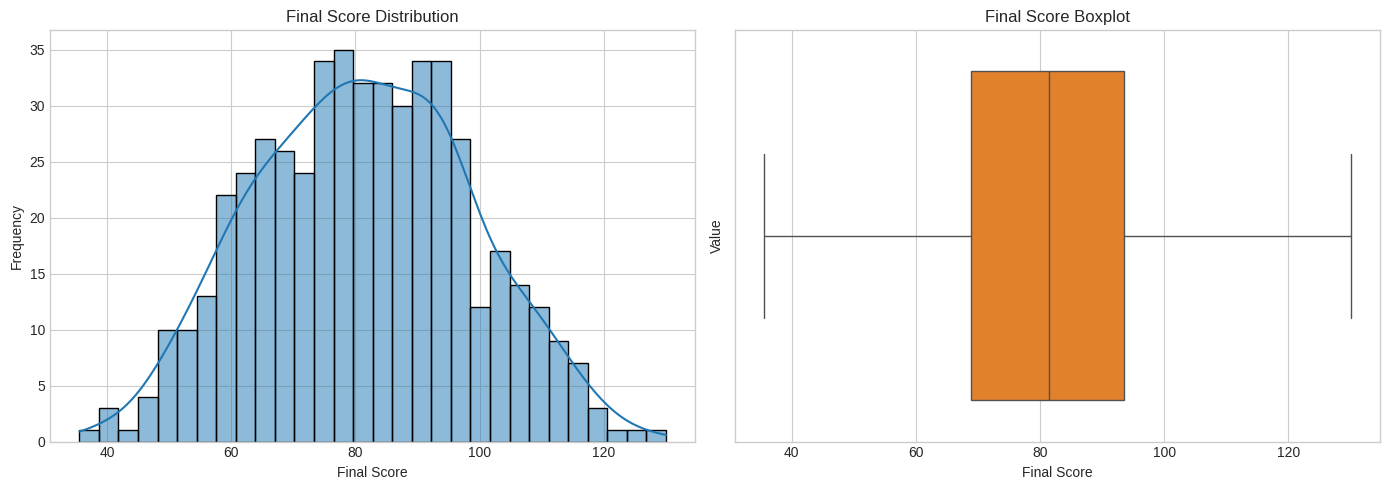

In [6]:
# Visualize the target distribution using a histogram and boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train[TARGET], bins=30, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Final Score Distribution')
axes[0].set_xlabel('Final Score')
axes[0].set_ylabel('Frequency')
sns.boxplot(x=train[TARGET], ax=axes[1], color='#ff7f0e')
axes[1].set_title('Final Score Boxplot')
axes[1].set_xlabel('Final Score')
axes[1].set_ylabel('Value')
plt.tight_layout()
plt.show()

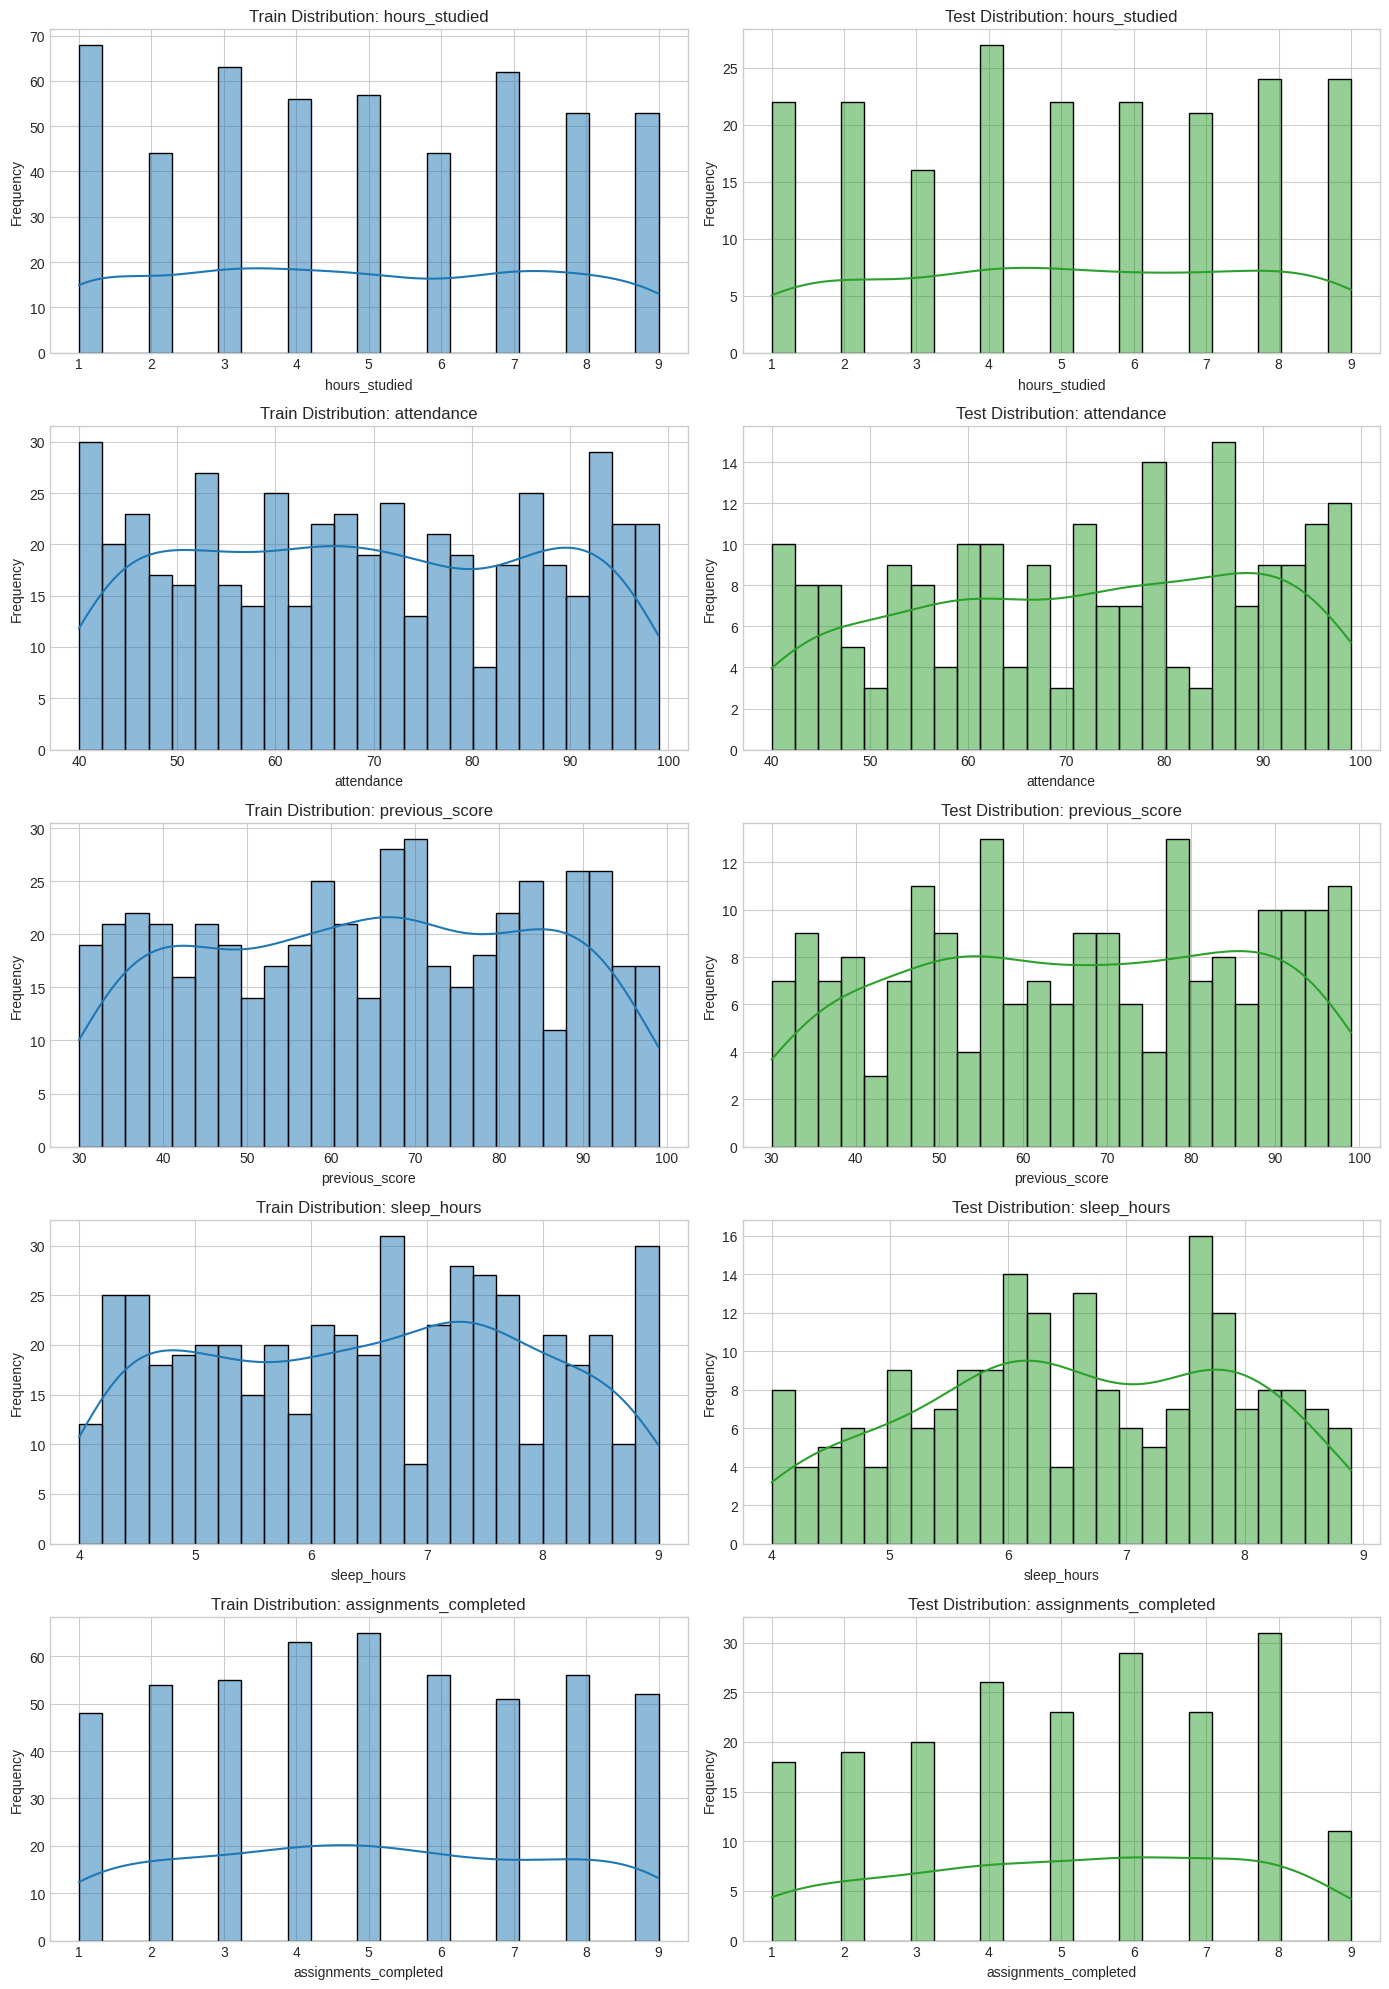

In [7]:
# Compare train and test feature distributions
fig, axes = plt.subplots(len(feature_cols), 2, figsize=(14, 4 * len(feature_cols)))
for row_idx, col in enumerate(feature_cols):
    sns.histplot(train[col], bins=25, kde=True, ax=axes[row_idx, 0], color='#1f77b4')
    axes[row_idx, 0].set_title(f'Train Distribution: {col}')
    axes[row_idx, 0].set_xlabel(col)
    axes[row_idx, 0].set_ylabel('Frequency')
    sns.histplot(test[col], bins=25, kde=True, ax=axes[row_idx, 1], color='#2ca02c')
    axes[row_idx, 1].set_title(f'Test Distribution: {col}')
    axes[row_idx, 1].set_xlabel(col)
    axes[row_idx, 1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

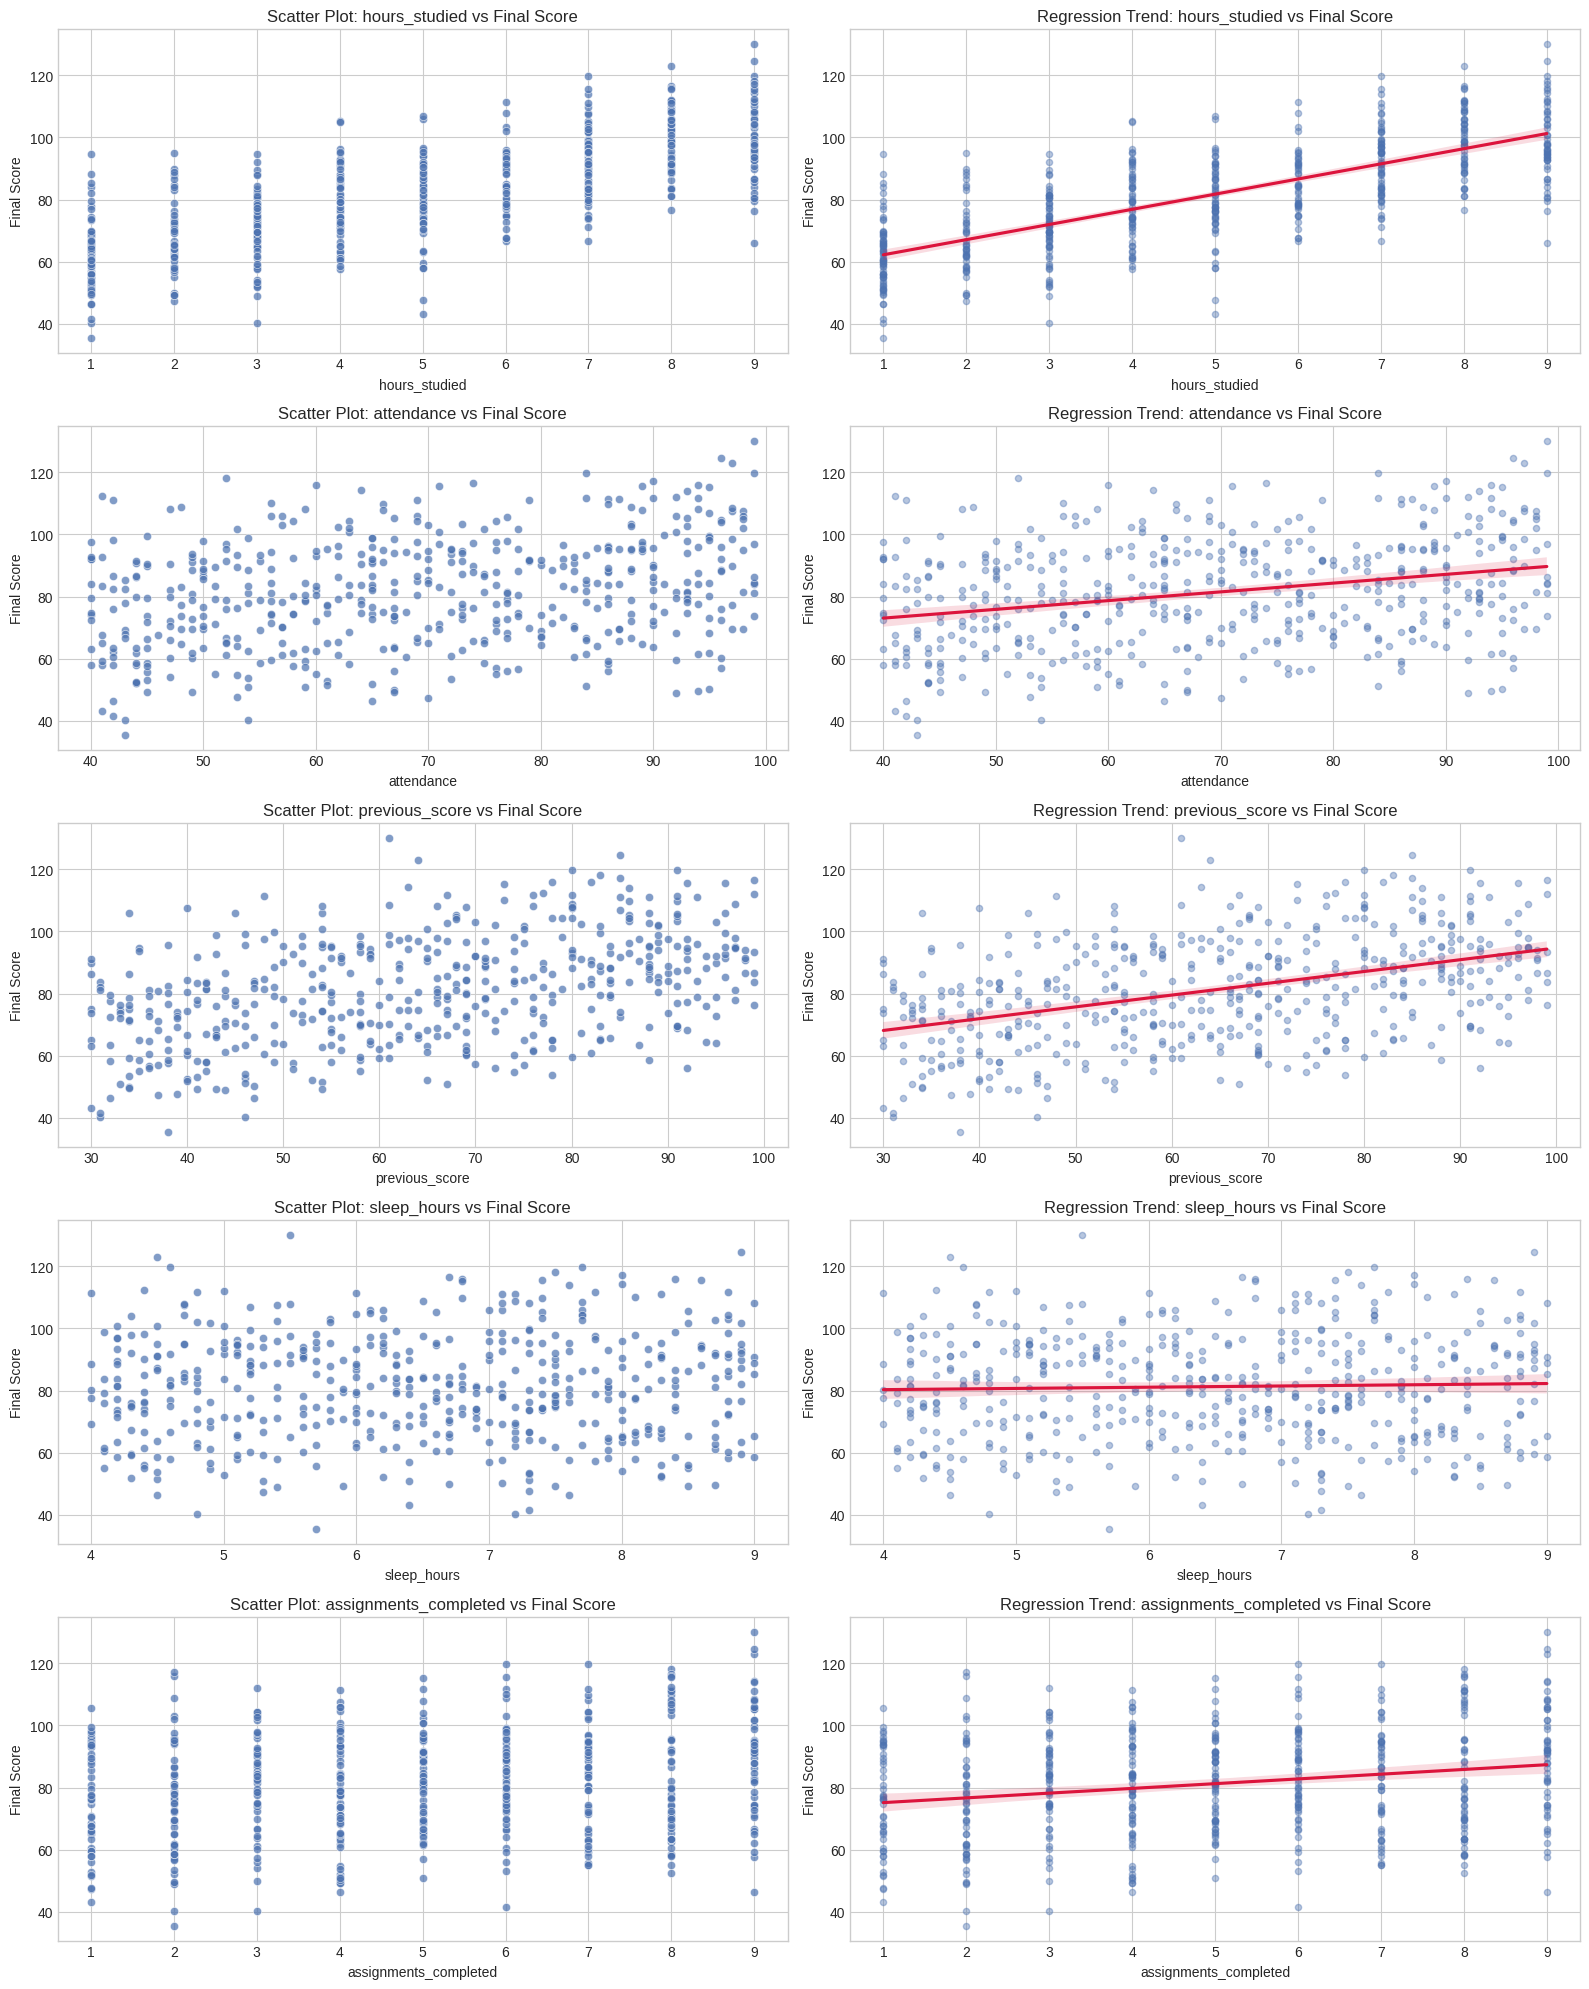

In [8]:
# Plot feature-target relationships
fig, axes = plt.subplots(len(feature_cols), 2, figsize=(16, 4 * len(feature_cols)))
for row_idx, col in enumerate(feature_cols):
    sns.scatterplot(data=train, x=col, y=TARGET, ax=axes[row_idx, 0], s=35, alpha=0.7)
    axes[row_idx, 0].set_title(f'Scatter Plot: {col} vs Final Score')
    axes[row_idx, 0].set_xlabel(col)
    axes[row_idx, 0].set_ylabel('Final Score')
    sns.regplot(data=train, x=col, y=TARGET, ax=axes[row_idx, 1], scatter_kws={'s': 20, 'alpha': 0.4}, line_kws={'color': 'crimson'})
    axes[row_idx, 1].set_title(f'Regression Trend: {col} vs Final Score')
    axes[row_idx, 1].set_xlabel(col)
    axes[row_idx, 1].set_ylabel('Final Score')
plt.tight_layout()
plt.show()

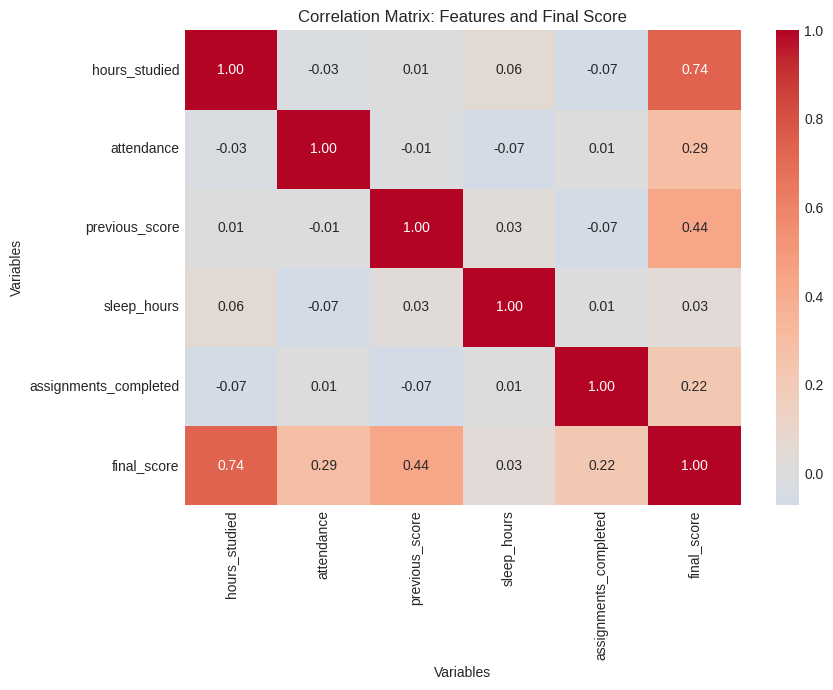

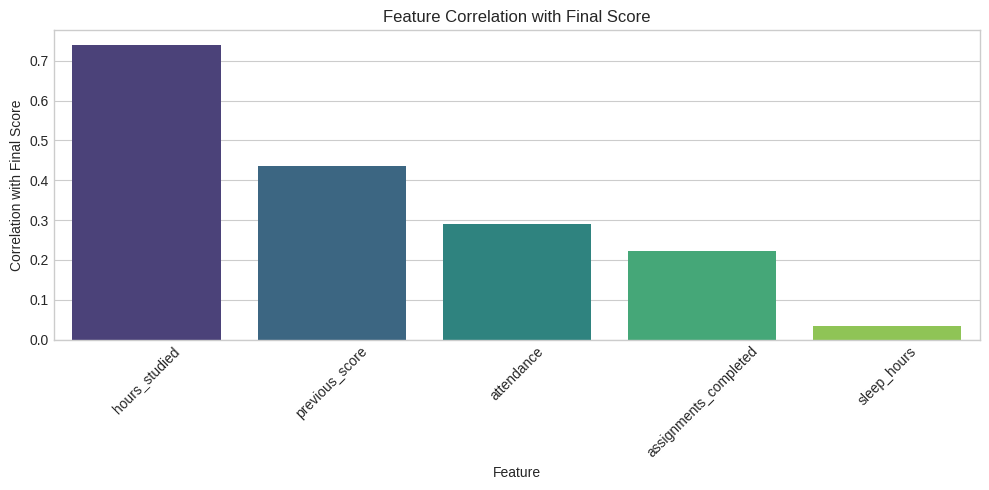

In [9]:
# Compute and visualize correlations
corr_matrix = train[feature_cols + [TARGET]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Features and Final Score')
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Rank feature-target correlations
corr_frame = corr_matrix[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False).reset_index()
corr_frame.columns = ['feature', 'correlation_with_target']
plt.figure(figsize=(10, 5))
sns.barplot(data=corr_frame, x='feature', y='correlation_with_target', palette='viridis')
plt.title('Feature Correlation with Final Score')
plt.xlabel('Feature')
plt.ylabel('Correlation with Final Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

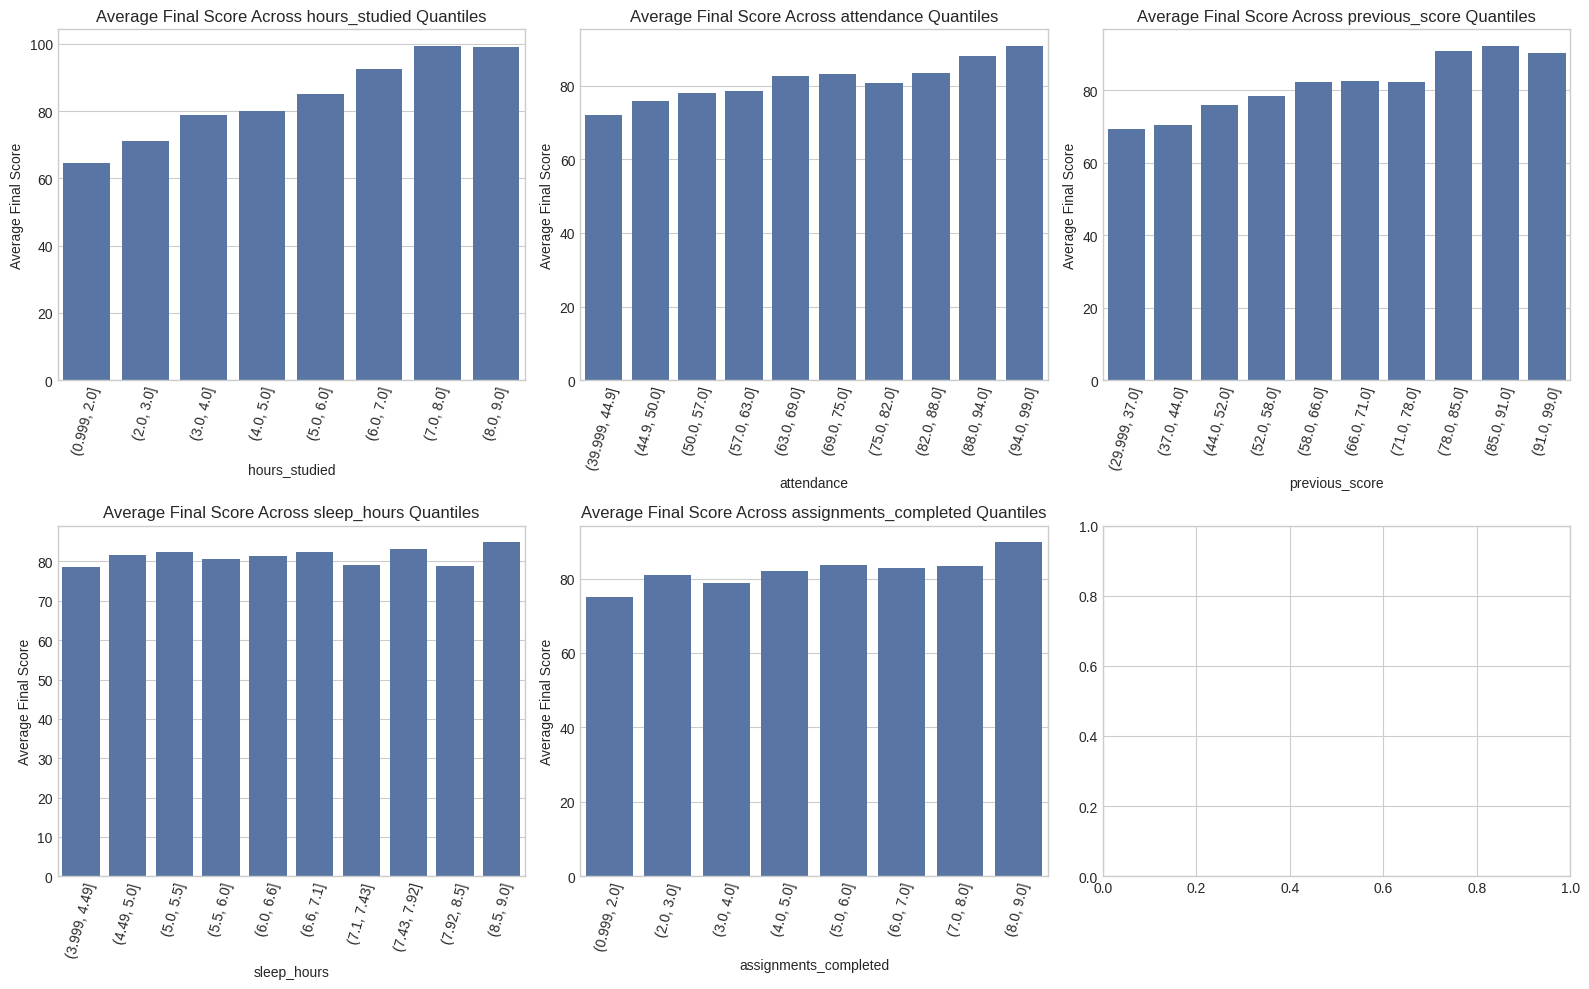

In [10]:
# Visualize binned target means
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for idx, col in enumerate(feature_cols):
    binned = pd.qcut(train[col], q=10, duplicates='drop')
    grouped = train.groupby(binned, observed=False)[TARGET].mean().reset_index()
    grouped[col] = grouped[col].astype(str)
    sns.barplot(data=grouped, x=col, y=TARGET, ax=axes[idx], color='#4c72b0')
    axes[idx].set_title(f'Average Final Score Across {col} Quantiles')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Average Final Score')
    axes[idx].tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [11]:
# Create interaction, ratio, difference, quadratic, and aggregate features
def build_features(df):
    engineered = df.copy()
    engineered['hours_x_attendance'] = engineered['hours_studied'] * engineered['attendance']
    engineered['hours_x_previous'] = engineered['hours_studied'] * engineered['previous_score']
    engineered['attendance_x_previous'] = engineered['attendance'] * engineered['previous_score']
    engineered['assignments_x_attendance'] = engineered['assignments_completed'] * engineered['attendance']
    engineered['sleep_x_hours'] = engineered['sleep_hours'] * engineered['hours_studied']
    engineered['hours_per_assignment'] = engineered['hours_studied'] / (engineered['assignments_completed'] + 1.0)
    engineered['assignments_per_hour'] = engineered['assignments_completed'] / (engineered['hours_studied'] + 1.0)
    engineered['previous_per_sleep'] = engineered['previous_score'] / (engineered['sleep_hours'] + 1.0)
    engineered['attendance_per_sleep'] = engineered['attendance'] / (engineered['sleep_hours'] + 1.0)
    engineered['previous_minus_attendance'] = engineered['previous_score'] - engineered['attendance']
    engineered['attendance_minus_sleep'] = engineered['attendance'] - engineered['sleep_hours']
    engineered['hours_minus_sleep'] = engineered['hours_studied'] - engineered['sleep_hours']
    engineered['hours_studied_sq'] = engineered['hours_studied'] ** 2
    engineered['attendance_sq'] = engineered['attendance'] ** 2
    engineered['previous_score_sq'] = engineered['previous_score'] ** 2
    engineered['sleep_hours_sq'] = engineered['sleep_hours'] ** 2
    engineered['assignments_completed_sq'] = engineered['assignments_completed'] ** 2
    engineered['academic_input_sum'] = engineered['hours_studied'] + engineered['attendance'] + engineered['previous_score'] + engineered['assignments_completed']
    engineered['academic_balance_mean'] = engineered[['hours_studied', 'attendance', 'previous_score', 'sleep_hours', 'assignments_completed']].mean(axis=1)
    engineered['academic_balance_std'] = engineered[['hours_studied', 'attendance', 'previous_score', 'sleep_hours', 'assignments_completed']].std(axis=1)
    return engineered

X_fe = build_features(X)
X_test_fe = build_features(X_test)
engineered_only = [col for col in X_fe.columns if col not in X.columns]
display(X_fe[engineered_only].describe().T)

,count,mean,std,min,25%,50%,75%,max
hours_x_attendance,500.0,337.958000,203.725748,41.000000,169.500000,319.000000,475.000000,891.000000
hours_x_previous,500.0,317.724000,200.742819,31.000000,151.500000,287.000000,469.250000,864.000000
attendance_x_previous,500.0,4468.718000,1794.955291,1230.000000,3131.000000,4200.000000,5754.000000,9506.000000
assignments_x_attendance,500.0,347.414000,199.234353,41.000000,191.500000,335.500000,469.000000,891.000000
sleep_x_hours,500.0,32.082800,19.449959,4.100000,16.725000,29.100000,45.000000,81.000000
hours_per_assignment,500.0,1.055169,0.906172,0.100000,0.428571,0.833333,1.400000,4.500000
assignments_per_hour,500.0,1.128555,0.943243,0.100000,0.500000,0.875000,1.400000,4.500000
previous_per_sleep,500.0,8.956394,3.349365,3.448276,6.293651,8.375593,11.104421,19.411765
attendance_per_sleep,500.0,9.633594,3.288367,4.040404,7.120244,9.278274,11.877264,19.038462
previous_minus_attendance,500.0,-4.520000,26.692970,-65.000000,-25.000000,-4.000000,15.000000,55.000000


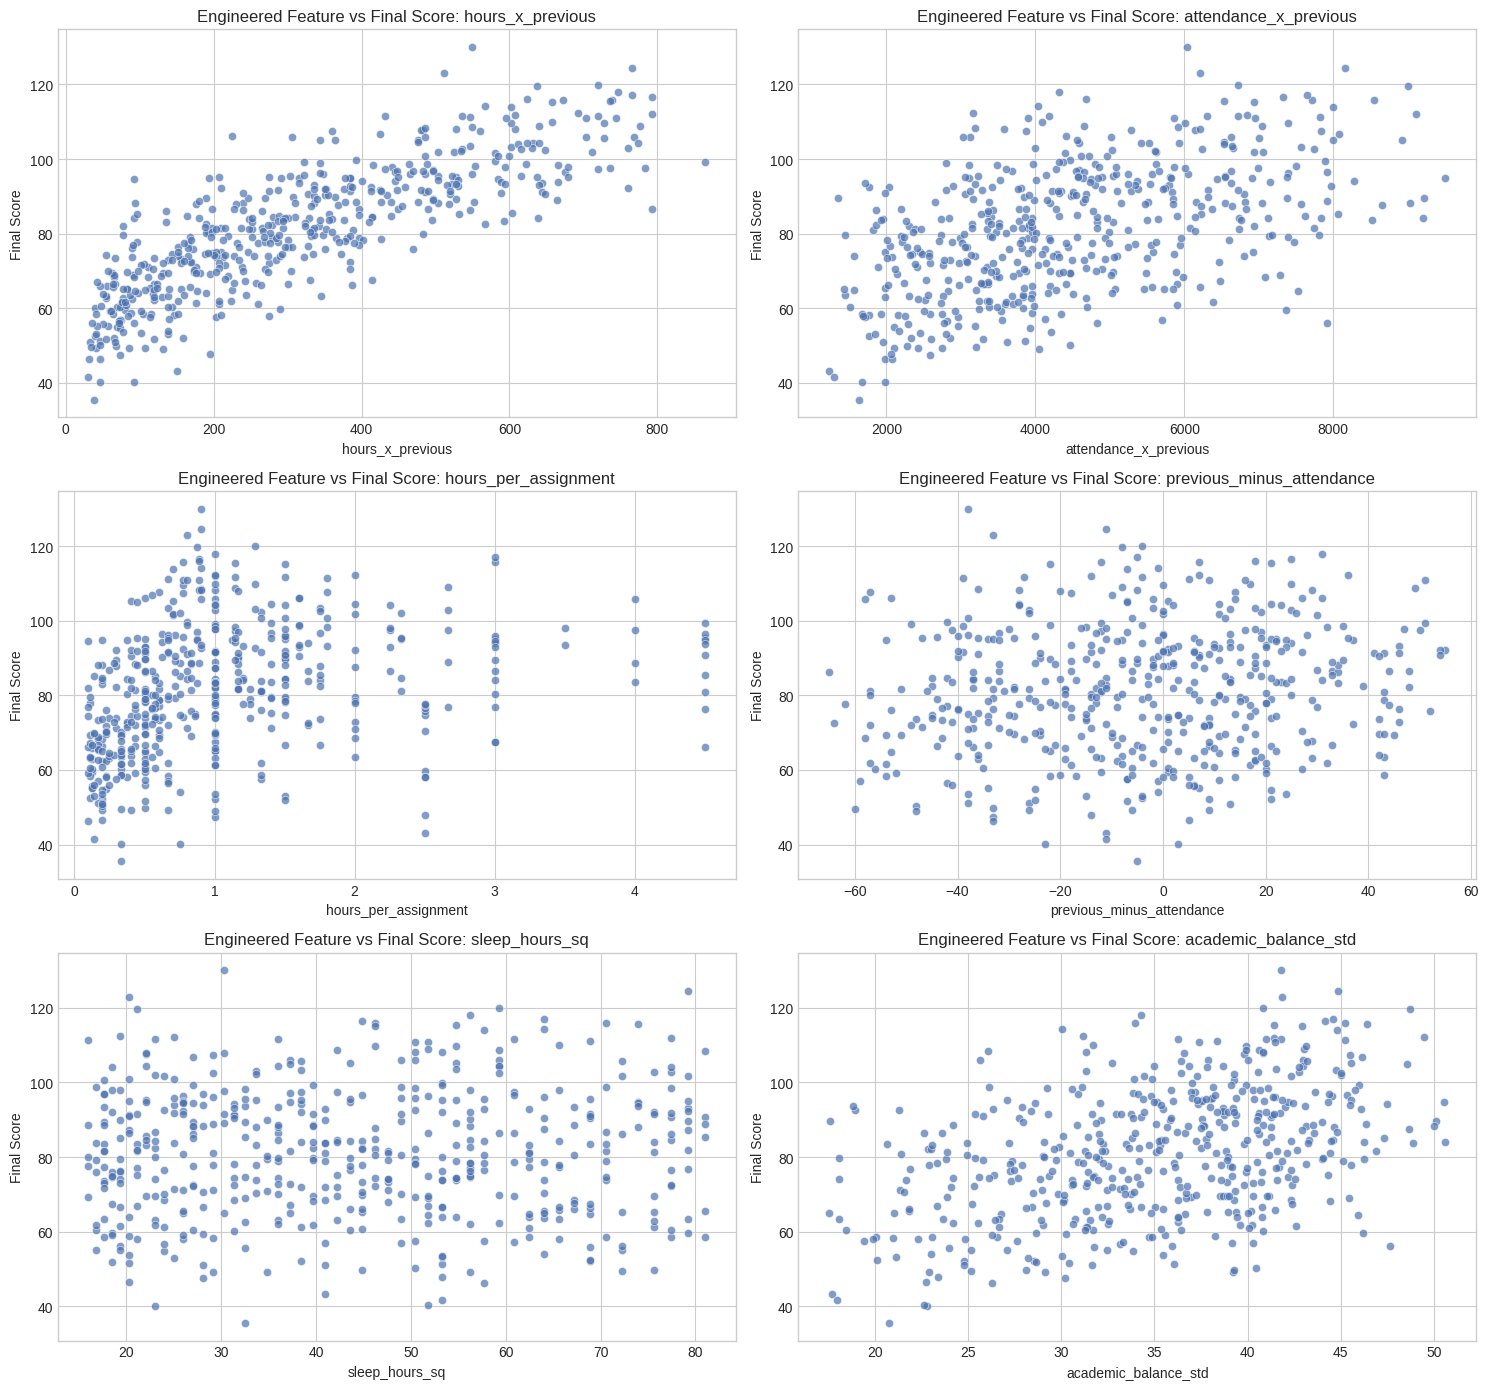

In [12]:
# Visualize selected engineered variables against the target
selected_engineered = ['hours_x_previous', 'attendance_x_previous', 'hours_per_assignment', 'previous_minus_attendance', 'sleep_hours_sq', 'academic_balance_std']
fig, axes = plt.subplots(3, 2, figsize=(15, 14))
axes = axes.flatten()
for idx, col in enumerate(selected_engineered):
    sns.scatterplot(x=X_fe[col], y=y, ax=axes[idx], s=35, alpha=0.7)
    axes[idx].set_title(f'Engineered Feature vs Final Score: {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Final Score')
plt.tight_layout()
plt.show()

## 6. Modeling

In [13]:
# Define a cross-validation function that returns OOF and test predictions
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def evaluate_model(model, X_data, y_data, X_holdout, cv_splitter, model_name):
    oof_pred = np.zeros(len(X_data))
    test_pred = np.zeros(len(X_holdout))
    fold_scores = []
    for fold_idx, (train_idx, valid_idx) in enumerate(cv_splitter.split(X_data, y_data), start=1):
        X_train_fold = X_data.iloc[train_idx]
        y_train_fold = y_data.iloc[train_idx]
        X_valid_fold = X_data.iloc[valid_idx]
        y_valid_fold = y_data.iloc[valid_idx]
        fitted_model = clone(model)
        fitted_model.fit(X_train_fold, y_train_fold)
        valid_pred = fitted_model.predict(X_valid_fold)
        oof_pred[valid_idx] = valid_pred
        test_pred += fitted_model.predict(X_holdout) / cv_splitter.n_splits
        fold_mae = mean_absolute_error(y_valid_fold, valid_pred)
        fold_scores.append(fold_mae)
        print(f'{model_name} | Fold {fold_idx:02d} | MAE: {fold_mae:.5f}')
    overall_mae = mean_absolute_error(y_data, oof_pred)
    return {'name': model_name, 'oof_pred': oof_pred, 'test_pred': test_pred, 'fold_scores': fold_scores, 'mae': overall_mae}

In [14]:
# Define preprocessing and regression models
linear_preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), X_fe.columns.tolist())
])

models = {
    'linear_regression': Pipeline([('preprocessor', linear_preprocessor), ('model', LinearRegression())]),
    'ridge_regression': Pipeline([('preprocessor', linear_preprocessor), ('model', Ridge(alpha=2.0, random_state=RANDOM_STATE))]),
    'elastic_net': Pipeline([('preprocessor', linear_preprocessor), ('model', ElasticNet(alpha=0.05, l1_ratio=0.2, random_state=RANDOM_STATE, max_iter=5000))]),
    'polynomial_ridge': Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('poly', PolynomialFeatures(degree=2, include_bias=False)), ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE))]),
    'random_forest': RandomForestRegressor(n_estimators=600, max_depth=8, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1),
    'extra_trees': ExtraTreesRegressor(n_estimators=700, max_depth=10, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1),
    'hist_gradient_boosting': HistGradientBoostingRegressor(learning_rate=0.03, max_depth=6, max_iter=500, min_samples_leaf=10, random_state=RANDOM_STATE, loss='absolute_error'),
    'knn_regressor': Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=9, weights='distance'))])
}
if CATBOOST_AVAILABLE:
    models['catboost'] = CatBoostRegressor(loss_function='MAE', depth=6, learning_rate=0.03, iterations=1200, l2_leaf_reg=4.0, random_seed=RANDOM_STATE, verbose=False)
if LGBM_AVAILABLE:
    models['lightgbm'] = LGBMRegressor(objective='mae', n_estimators=1200, learning_rate=0.03, num_leaves=31, subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE)
if XGB_AVAILABLE:
    models['xgboost'] = XGBRegressor(n_estimators=1400, learning_rate=0.025, max_depth=4, min_child_weight=3, subsample=0.9, colsample_bytree=0.9, reg_alpha=0.2, reg_lambda=1.0, objective='reg:absoluteerror', random_state=RANDOM_STATE, verbosity=0)

In [15]:
# Train all models under the same cross-validation setup
results = []
for model_name, model in models.items():
    print('=' * 70)
    result = evaluate_model(model, X_fe, y, X_test_fe, cv, model_name)
    results.append(result)
    print(f"{model_name} | OOF MAE: {result['mae']:.5f}")

linear_regression | Fold 01 | MAE: 4.08028
linear_regression | Fold 02 | MAE: 3.66808
linear_regression | Fold 03 | MAE: 3.84584
linear_regression | Fold 04 | MAE: 4.12163
linear_regression | Fold 05 | MAE: 3.47593
linear_regression | Fold 06 | MAE: 4.32339
linear_regression | Fold 07 | MAE: 4.60483
linear_regression | Fold 08 | MAE: 3.84145
linear_regression | Fold 09 | MAE: 3.38286
linear_regression | Fold 10 | MAE: 4.01840
linear_regression | OOF MAE: 3.93627
ridge_regression | Fold 01 | MAE: 4.11379
ridge_regression | Fold 02 | MAE: 3.61060
ridge_regression | Fold 03 | MAE: 3.85947
ridge_regression | Fold 04 | MAE: 4.14643
ridge_regression | Fold 05 | MAE: 3.38973
ridge_regression | Fold 06 | MAE: 4.39493
ridge_regression | Fold 07 | MAE: 4.57757
ridge_regression | Fold 08 | MAE: 3.88639
ridge_regression | Fold 09 | MAE: 3.44749
ridge_regression | Fold 10 | MAE: 4.03855
ridge_regression | OOF MAE: 3.94649
elastic_net | Fold 01 | MAE: 4.21450
elastic_net | Fold 02 | MAE: 3.73034
ela

## 7. Evaluation

,model,oof_mae,fold_mae_mean,fold_mae_std
0,linear_regression,3.936270,3.936270,0.355801
1,ridge_regression,3.946494,3.946494,0.368617
2,elastic_net,3.999245,3.999245,0.398097
3,polynomial_ridge,4.140838,4.140838,0.508997
4,catboost,4.195377,4.195377,0.544348
5,extra_trees,4.357746,4.357746,0.438889
6,xgboost,4.365089,4.365089,0.468640
7,hist_gradient_boosting,4.367987,4.367987,0.529211
8,lightgbm,4.418561,4.418561,0.563227
9,random_forest,4.587396,4.587396,0.407144


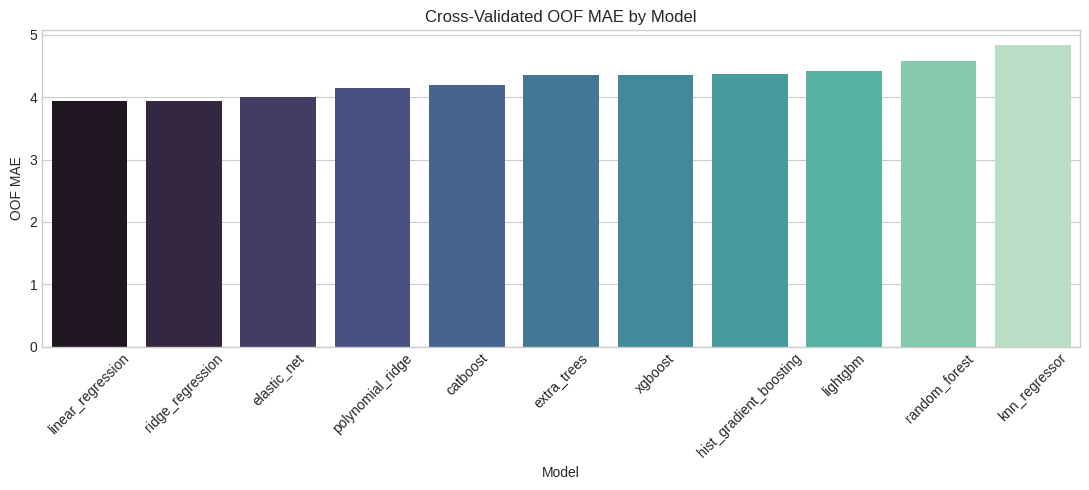

In [16]:
# Summarize model ranking and fold stability
results_df = pd.DataFrame({
    'model': [res['name'] for res in results],
    'oof_mae': [res['mae'] for res in results],
    'fold_mae_mean': [np.mean(res['fold_scores']) for res in results],
    'fold_mae_std': [np.std(res['fold_scores']) for res in results]
}).sort_values('oof_mae').reset_index(drop=True)
display(results_df)

# Plot OOF MAE ranking across all trained models
plt.figure(figsize=(11, 5))
sns.barplot(data=results_df, x='model', y='oof_mae', palette='mako')
plt.title('Cross-Validated OOF MAE by Model')
plt.xlabel('Model')
plt.ylabel('OOF MAE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

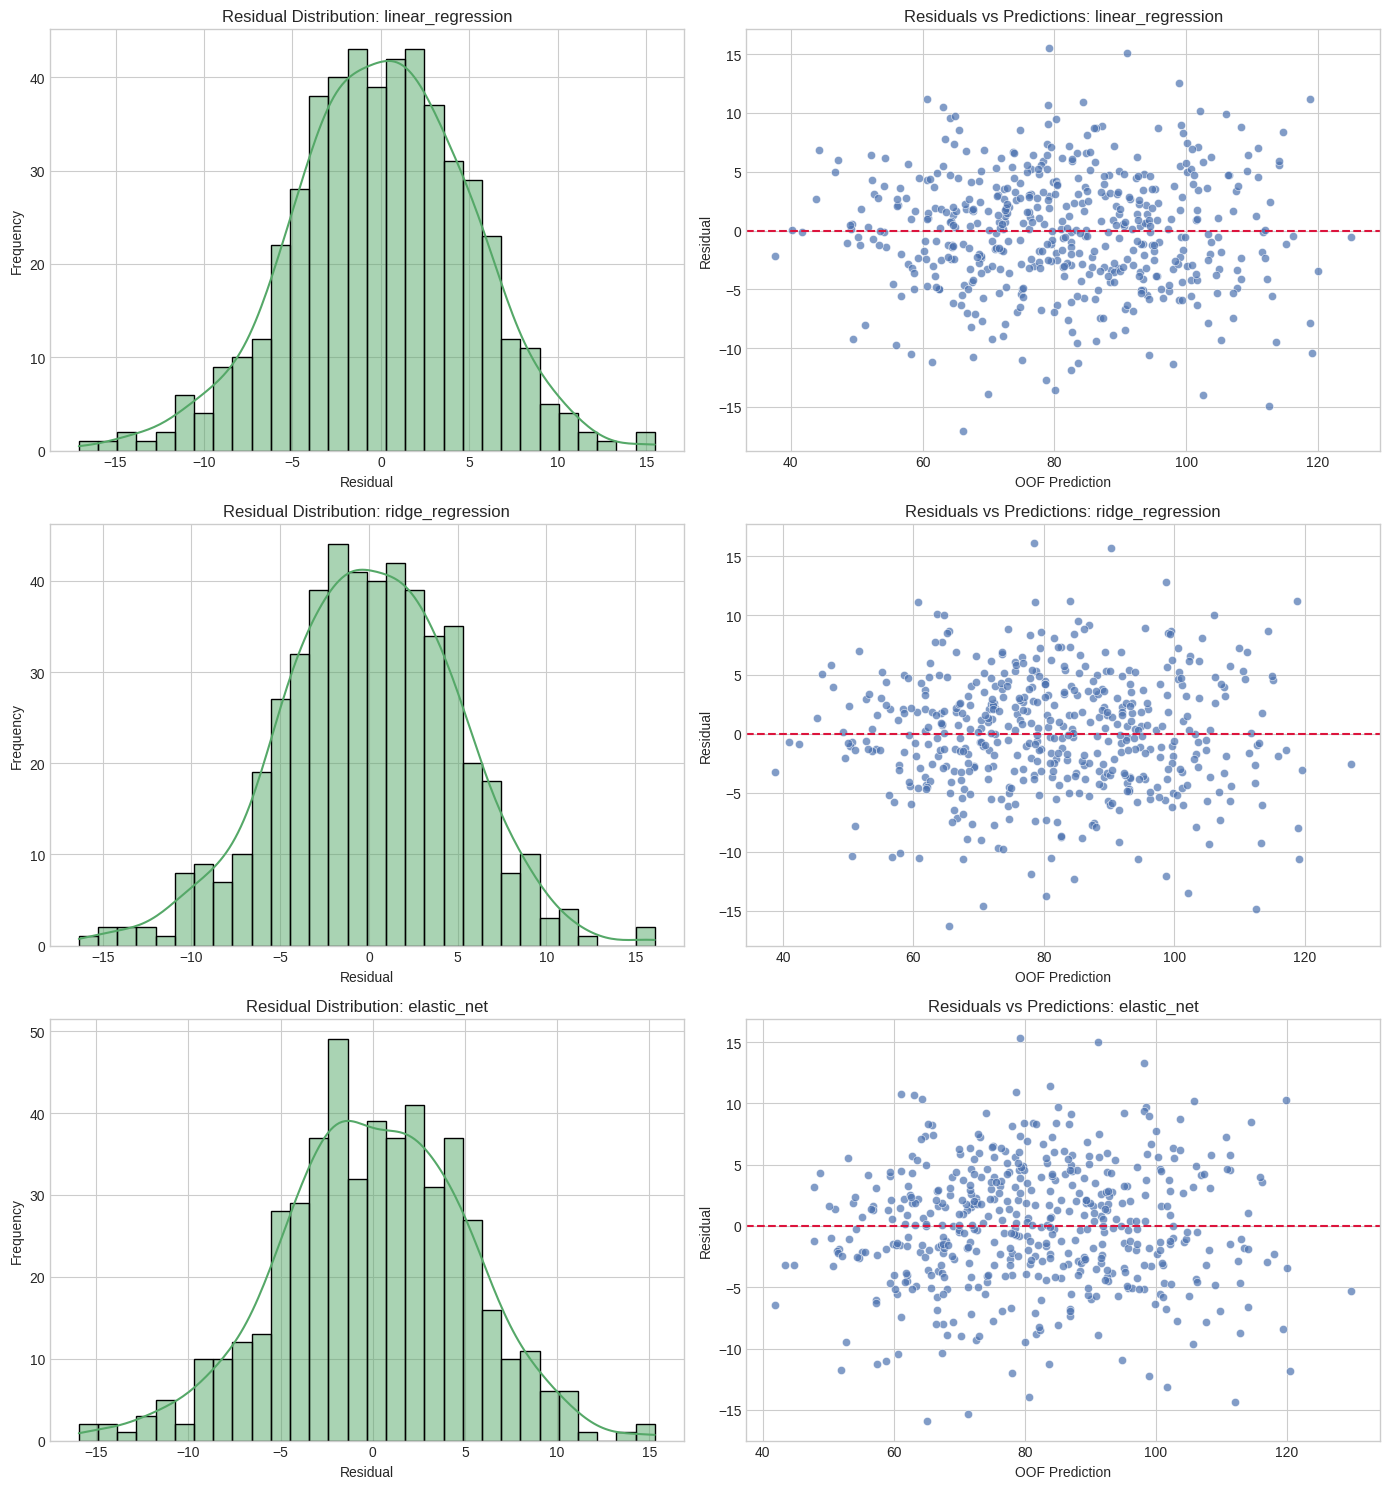

In [17]:
# Plot residual diagnostics for the top three models
top_models = results_df.head(3)['model'].tolist()
fig, axes = plt.subplots(len(top_models), 2, figsize=(14, 5 * len(top_models)))
if len(top_models) == 1:
    axes = np.array([axes])
for row_idx, model_name in enumerate(top_models):
    res = next(item for item in results if item['name'] == model_name)
    residuals = y.values - res['oof_pred']
    sns.histplot(residuals, bins=30, kde=True, ax=axes[row_idx, 0], color='#55a868')
    axes[row_idx, 0].set_title(f'Residual Distribution: {model_name}')
    axes[row_idx, 0].set_xlabel('Residual')
    axes[row_idx, 0].set_ylabel('Frequency')
    sns.scatterplot(x=res['oof_pred'], y=residuals, ax=axes[row_idx, 1], s=35, alpha=0.7)
    axes[row_idx, 1].axhline(0, color='crimson', linestyle='--')
    axes[row_idx, 1].set_title(f'Residuals vs Predictions: {model_name}')
    axes[row_idx, 1].set_xlabel('OOF Prediction')
    axes[row_idx, 1].set_ylabel('Residual')
plt.tight_layout()
plt.show()

In [18]:
# Search a nonnegative weighted ensemble over the top three models
top_three = results_df.head(3)['model'].tolist()
top_three_results = [next(item for item in results if item['name'] == model_name) for model_name in top_three]
weight_grid = np.linspace(0.0, 1.0, 21)
best_score = np.inf
best_weights = None
for w1 in weight_grid:
    for w2 in weight_grid:
        w3 = 1.0 - w1 - w2
        if w3 < 0:
            continue
        ensemble_oof = w1 * top_three_results[0]['oof_pred'] + w2 * top_three_results[1]['oof_pred'] + w3 * top_three_results[2]['oof_pred']
        ensemble_mae = mean_absolute_error(y, ensemble_oof)
        if ensemble_mae < best_score:
            best_score = ensemble_mae
            best_weights = (w1, w2, w3)

best_test_pred = best_weights[0] * top_three_results[0]['test_pred'] + best_weights[1] * top_three_results[1]['test_pred'] + best_weights[2] * top_three_results[2]['test_pred']
print(top_three)
print(best_weights)
print(best_score)

['linear_regression', 'ridge_regression', 'elastic_net']
(np.float64(0.75), np.float64(0.0), np.float64(0.25))
3.9294697845409874


In [19]:
# Select between the best single model and the weighted ensemble
best_single_model_name = results_df.iloc[0]['model']
best_single_result = next(item for item in results if item['name'] == best_single_model_name)
if best_score < best_single_result['mae']:
    final_predictions = best_test_pred
else:
    final_predictions = best_single_result['test_pred']

# Create the final submission file
submission = sample_submission.copy()
submission[ID_COL] = test_ids
submission[TARGET] = final_predictions
display(submission.head())
submission.to_csv('submission.csv', index=False)

,id,final_score
0,1,91.568532
1,2,110.074814
2,3,94.484943
3,4,92.387378
4,5,66.545817


## 8. Conclusion

- The notebook inspects the dataset, studies feature-target patterns, engineers additional variables, and compares several regression models.
- Visual analysis covers distributions, feature-target plots, correlations, and residual diagnostics.
- Added features include interactions, ratios, differences, quadratic terms, and summary statistics.
- Model comparison is based on cross-validated MAE.
- The notebook writes `submission.csv` in the required format.

## 9. References

- BMSCE IEEE Computer Society. *CS Week Codeathon AIML (Easy Level).* https://kaggle.com/competitions/bmsce-ieee-computer-society-cs-week-code-a-thon-aiml
- Pedregosa, F. et al. *Scikit-learn: Machine Learning in Python.* Journal of Machine Learning Research, 2011.
- Chen, T., Guestrin, C. *XGBoost: A Scalable Tree Boosting System.* KDD 2016.
- Ke, G. et al. *LightGBM: A Highly Efficient Gradient Boosting Decision Tree.* NeurIPS 2017.
- Prokhorenkova, L. et al. *CatBoost: Unbiased Boosting with Categorical Features.* NeurIPS 2018.